# Hand Gesture Recognition

In [1]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from scipy.fft import fft, fftfreq
from scipy import signal
from scipy.signal import butter
from numpy import mean, std

from enum import IntEnum

import neurokit2 as nk
from sklearn.preprocessing import RobustScaler

from pickle import dump

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import libemg

import gc

In [2]:
# global variables
test_subject = "nad"
base_dir = "../../recordings"
num_classes = 6
lf = 20
hf = 500
fs = 1150
trim = 4 * 8 * 5
bandpass_order = 4
outlier_rejection_stds = 6

plot_all_timeline = False
num_sensors = 4
random_state = 42

In [3]:
class Classes(IntEnum):
    # NEUTRAL = 0,
    FIST = 0,
    INDEX = 1,
    MIDDLE = 2,
    OK = 3,
    PEACE = 4,
    THUMB = 5
    
# structure: recordings/date/data/*.csv
files = [[] for _ in range(num_classes)]
baseline_file = None

for date_dir, _, filenames in os.walk(base_dir):
    if date_dir.endswith('data'):
        for filename in filenames:
            if not filename.startswith(test_subject):
                continue
            if filename.find('baseline') != -1:
                baseline_file = os.path.join(date_dir, filename)
            elif filename.find('fist') != -1:
                files[Classes.FIST].append(os.path.join(date_dir, filename))
            elif filename.find('index') != -1:
                files[Classes.INDEX].append(os.path.join(date_dir, filename))
            elif filename.find('middle') != -1:
                files[Classes.MIDDLE].append(os.path.join(date_dir, filename))
            elif filename.find('ok') != -1:
                files[Classes.OK].append(os.path.join(date_dir, filename))
            elif filename.find('peace') != -1:
                files[Classes.PEACE].append(os.path.join(date_dir, filename))
            elif filename.find('thumb') != -1:
                files[Classes.THUMB].append(os.path.join(date_dir, filename))

files = [file for file in files if len(file) > 0]
print(files)      

[['../../recordings/01_12_24_initial_placement_test/data/nad_fist_0.csv', '../../recordings/19_12_24/data/nad_fist_0.csv'], ['../../recordings/01_12_24_initial_placement_test/data/nad_index_0.csv', '../../recordings/19_12_24/data/nad_index_0.csv'], ['../../recordings/01_12_24_initial_placement_test/data/nad_middle_0.csv', '../../recordings/19_12_24/data/nad_middle_0.csv'], ['../../recordings/01_12_24_initial_placement_test/data/nad_ok_0.csv', '../../recordings/19_12_24/data/nad_ok_0.csv'], ['../../recordings/01_12_24_initial_placement_test/data/nad_peace_0.csv', '../../recordings/19_12_24/data/nad_peace_0.csv'], ['../../recordings/01_12_24_initial_placement_test/data/nad_thumb_0.csv', '../../recordings/19_12_24/data/nad_thumb_0.csv']]


Our initial static gesture recording includes 7 classes: neutral, fist, index finger, middle finger, ok, peace, thumb.

In [4]:
# neutral_df = [pd.read_csv(file, header=None) for file in files[Classes.NEUTRAL]]
fist_df = [pd.read_csv(file, header=None) for file in files[Classes.FIST]]
index_df = [pd.read_csv(file, header=None) for file in files[Classes.INDEX]]
middle_df = [pd.read_csv(file, header=None) for file in files[Classes.MIDDLE]]
ok_df = [pd.read_csv(file, header=None) for file in files[Classes.OK]]
peace_df = [pd.read_csv(file, header=None) for file in files[Classes.PEACE]]
thumb_df = [pd.read_csv(file, header=None) for file in files[Classes.THUMB]]
baseline_df = pd.read_csv(baseline_file, header=None)

Optional subsampling:

In [5]:
def get_min_df_array_len(dfs):
    min_len = min([len(df_) for df in dfs for df_ in df])
    return min_len

def get_min_df_len(dfs):
    min_len = min([len(df) for df in dfs])
    return min_len

In [6]:
num_samples = get_min_df_array_len([fist_df, index_df, middle_df, ok_df, peace_df, thumb_df])

fist_df = pd.concat([df.sample(num_samples, random_state=random_state) for df in fist_df])
index_df = pd.concat([df.sample(num_samples, random_state=random_state) for df in index_df])
middle_df = pd.concat([df.sample(num_samples, random_state=random_state) for df in middle_df])
ok_df = pd.concat([df.sample(num_samples, random_state=random_state) for df in ok_df])
peace_df = pd.concat([df.sample(num_samples, random_state=random_state) for df in peace_df])
thumb_df = pd.concat([df.sample(num_samples, random_state=random_state) for df in thumb_df])

min_len = get_min_df_len([fist_df, index_df, middle_df, ok_df, peace_df, thumb_df])
print('Min length of combined dataframes:', min_len)
baseline_array = baseline_df.values
if min_len > len(baseline_array):
    baseline_array = np.concatenate([baseline_array for _ in range(min_len // len(baseline_array))])
    baseline_array = np.concatenate([baseline_array, baseline_array[:min_len % len(baseline_array)]])
else:
    baseline_array = baseline_array[:min_len]

Min length of combined dataframes: 9108


In [7]:
len(fist_df), len(index_df), len(middle_df), len(ok_df), len(peace_df), len(thumb_df), len(baseline_array)

(9108, 9108, 9108, 9108, 9108, 9108, 9108)

In [8]:
ok_df.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
4089,18303,18324,18301,18324,18335,18302,18297,18296,17899,17896,...,18295,18309,17699,17694,17711,17717,17715,17719,17715,17737
1139,17867,17865,17852,17842,17852,17822,17815,17775,17782,17746,...,18469,18144,17959,17963,17986,17930,17916,17872,17905,17943
2478,17772,17791,17799,17788,17795,17780,17758,17775,17975,17998,...,17322,17322,18175,18194,18244,18261,18259,18266,18270,18288
9845,18517,18512,18475,18442,18385,18358,18363,18408,18227,18260,...,18360,18429,18186,18185,18183,18187,18213,18179,18189,18196
9584,17877,17868,17900,17957,18016,18027,18009,18013,17787,17776,...,17254,17418,18008,18013,17989,18038,18076,18058,17976,17935


Combine dataframes

In [9]:
sensor_data = pd.concat([fist_df, index_df, middle_df, ok_df, peace_df, thumb_df], ignore_index=True)
labels = [Classes.FIST]*len(fist_df) + [Classes.INDEX]*len(index_df) + [Classes.MIDDLE]*len(middle_df) + [Classes.OK]*len(ok_df) + [Classes.PEACE]*len(peace_df) + [Classes.THUMB]*len(thumb_df)
print(sensor_data.head())

      0      1      2      3      4      5      6      7      8      9   ...  \
0  18203  18191  18210  18171  18094  17971  17990  18131  17871  17831  ...   
1  17687  17735  17751  17807  17821  17806  17785  17728  17688  17699  ...   
2  18023  18087  18143  18226  18175  18146  18096  18097  17644  17519  ...   
3  18409  18471  18581  18610  18647  18664  18685  18693  18269  18251  ...   
4  18506  18466  18490  18575  18634  18632  18592  18551  18401  18384  ...   

      22     23     24     25     26     27     28     29     30     31  
0  18285  18248  18057  18157  18319  18281  18412  18619  18455  17930  
1  18455  18342  18163  18167  18177  18181  18214  18249  18256  18208  
2  17325  17322  18461  18548  18373  18259  18196  18236  18265  18583  
3  17796  17819  18553  18560  18464  18095  17699  17528  17837  18294  
4  17752  17813  18251  18229  18201  18425  18551  18496  18434  18311  

[5 rows x 32 columns]


## Preprocessing

In [10]:
import libemg
import neurokit2 as nk
import numpy as np
from numpy import mean, std
from scipy import signal
from scipy.signal import butter


class EMG_preprocessor():
    def __init__(self, lf, hf, fs, trim, filter_order, outlier_rejection_stds, baseline_signal=None, filter_type='band', library='scipy', num_sensors=4):
        self.lf = lf
        self.hf = hf
        self.fs = fs
        self.trim = trim
        self.filter_order = filter_order
        self.outlier_rejection_stds = outlier_rejection_stds
        self.filter_type = filter_type
        self.library = library
        self.num_sensors = num_sensors
        self.baseline_mean = [[0.0] for _ in range(num_sensors)]
        self.baseline_noise = [[0.0] for _ in range(num_sensors)]
        if baseline_signal is not None:
            self.baseline_signal = [[] for _ in range(num_sensors)]
            baseline_signal = np.array_split(baseline_signal, num_sensors)
            for i in range(num_sensors):
                self.baseline_signal[i] = np.asarray(baseline_signal[i]).flatten()
                
            print('Baseline signal provided')
            self._calculate_baseline_noise(filter=True) # calculates baseline noise for each sensor
            self._calculate_baseline_mean() # calculates baseline mean for each sensor
            for i in range(num_sensors):
                self.baseline_signal[i] = self.baseline_signal[i] - self.baseline_mean[i]
        else:
            self.baseline_signal = None

    def calibrate(self, sensor_data):
        self.library = self._maximize_SNR(sensor_data)

    def preprocess(self, sensor_data, sensor_num):
        if self.library == 'scipy':
            return self._preprocess_data_scipy(sensor_data, sensor_num)
        elif self.library == 'nk2':
            return self._preprocess_data_nk2(sensor_data, sensor_num)
        elif self.library == 'libemg':
            return self._preprocess_data_libemg(sensor_data, sensor_num)
        else:
            return sensor_data
        
    def _preprocess_data_libemg(self, data, sensor_num):
        # instantiate the filter object with the sampling frequency
        fi = libemg.filtering.Filter(self.fs)
        # install filters to the filter object
        fi.install_common_filters()
        # run the entire first subject dataset through the common filters
        raw_data = fi.filter(data)
        return raw_data

    def _preprocess_data_nk2(self, data, sensor_num):
        # raw_data = self._apply_filter(data)
        # raw_data = self._remove_artefact(raw_data)
        raw_data = data
        # raw_data = self._subtract_baseline(raw_data, sensor_num)
        raw_data = self._calculate_linear_envelop(raw_data, sensor_num, plot=False)
        return raw_data

    def _calculate_linear_envelop(self, data, sensor_num, plot=False):
        feature='EMG_Amplitude'
        signals, info = nk.emg_process(data, sampling_rate=self.fs)
        if plot:
            nk.emg_plot(signals, info)
        return signals[feature].values
    
    # def _preprocess_data_emg_dsp_lib(self, data, sensor_num):
    #     ref_available = True if self.baseline_signal is not None else False
    #     self.emg_filter = EMG_filter(sample_frequency = self.fs, range_ = 0.5, min_EMG_frequency = self.lf, max_EMG_frequency = self.hf, reference_available = ref_available)
    #     sig = self.emg_filter.filter(data, self.baseline_signal[sensor_num].tolist())
    #     return sig

    def _remove_mean(self, data):
        return data - np.mean(data, axis=0)

    def _preprocess_data_scipy(self, data, sensor_num):
        data = self._apply_filter(data)
        data = self._remove_artefact(data)
        data = self._remove_outliers(data)
        data = self._remove_mean(data)
        data = self._subtract_baseline(data, sensor_num)
        return data
    
    def _preprocess_baseline_scipy(self, data):
        data = self._apply_filter(data)
        data = self._remove_artefact(data)
        data = self._remove_outliers(data)
        return data
    
    def _apply_filter(self, data):
        if self.filter_type == 'band':
            return self._apply_bandpass_filter(data)
        elif self.filter_type == 'highlow':
            return self._apply_highpasslowpass_filter(data)
        else:
            return data

    def _apply_bandpass_filter(self, data):
        sos = butter(self.filter_order, (self.lf, self.hf), btype="bandpass", fs=self.fs, output="sos")
        proc_data = signal.sosfilt(sos, data)
        return proc_data
    
    def _apply_highpasslowpass_filter(self, data):
        sos = butter(self.filter_order, self.lf, btype="highpass", fs=self.fs, output="sos")
        proc_data = signal.sosfilt(sos, data)
        sos = butter(self.filter_order, self.hf, btype="lowpass", fs=self.fs, output="sos")
        proc_data = signal.sosfilt(sos, proc_data)
        return proc_data

    def _remove_outliers(self, data):
        raw_data = data.flatten()
        data_mean, data_std = mean(raw_data), std(raw_data)
        cut_off = data_std * self.outlier_rejection_stds
        lower, upper = data_mean - cut_off, data_mean + cut_off

        outliers_removed = [x if x >= lower and x <= upper else 0.0 for x in raw_data]
        return outliers_removed

    def _remove_artefact(self, data):
        data[:self.trim] = 0
        return data
    
    def _calculate_baseline_mean(self):
        for i in range(self.num_sensors):
            self.baseline_mean[i] = np.mean(self.baseline_signal[i], axis=0)
    
    def _calculate_baseline_noise(self, filter=False):
        for i in range(self.num_sensors):
            baseline_signal = self.baseline_signal[i]
            if filter:
                baseline_signal = self._preprocess_baseline_scipy(baseline_signal)
            self.baseline_noise[i] = np.sqrt(np.sum(np.asanyarray(baseline_signal)**2)) / len(baseline_signal)
            print('Baseline noise: ', self.baseline_noise[i])
    
    def signaltonoise(self, signal, sensor_num):
        power_signal = np.sqrt(np.sum(np.asanyarray(signal)**2)) / len(signal)
        snr = 10 * np.log10(power_signal / self.baseline_noise[sensor_num])
        return snr

    def _subtract_baseline(self, data, sensor_num):
        return data - self.baseline_signal[sensor_num]

# Data visualization

## Sensor signals

In [11]:
def plot_time_signals(dataframe, row_index, title):
    row_data = dataframe.iloc[row_index, :]

    # Split the row into 8 groups corresponding to sensors
    signals = np.array_split(row_data.values, num_sensors)

    # Plot each sensor's signal
    plt.figure(figsize=(12, 6))
    for i, signal in enumerate(signals):
        plt.plot(signal, label=f'Sensor {i + 1}')
    
    plt.title(f"{title} (Row {row_index})")
    plt.xlabel("Time Steps")
    plt.ylabel("Signal Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_all_time_signals(dataframe, title):    
    # Plot each sensor's signal
    signals = np.array_split(dataframe.values, num_sensors)
    fig, axs = plt.subplots(2, 2, figsize=(24, 16))
    axs = axs.flatten()
    for sensor in range(0, num_sensors):
        sigs = signals[sensor]
        sigs = np.array(sigs).flatten()
        axs[sensor].set_title(f'Sensor {sensor + 1}')
        axs[sensor].plot(sigs)
    fig.suptitle(title)
    
    plt.show()

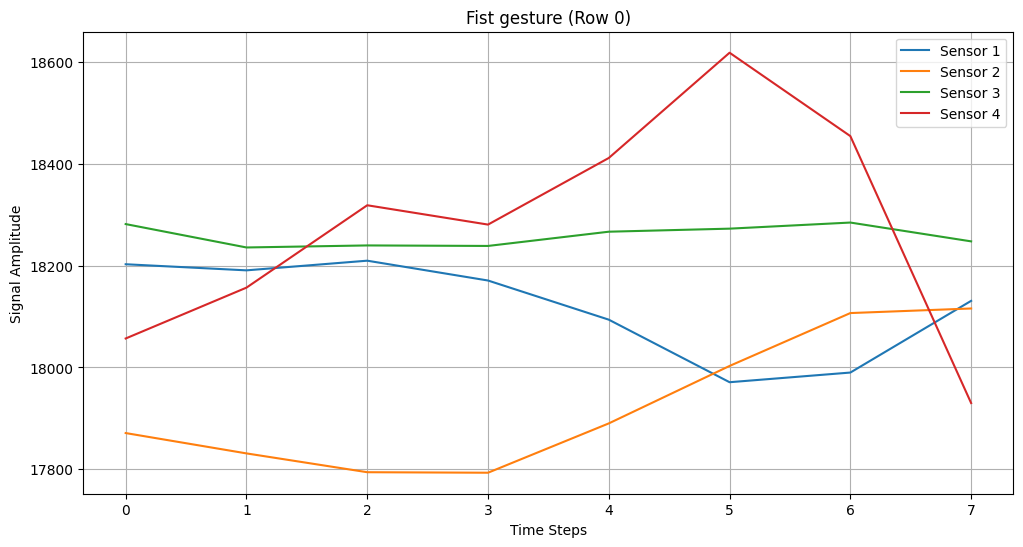

In [12]:
plot_time_signals(fist_df, row_index=0, title='Fist gesture')

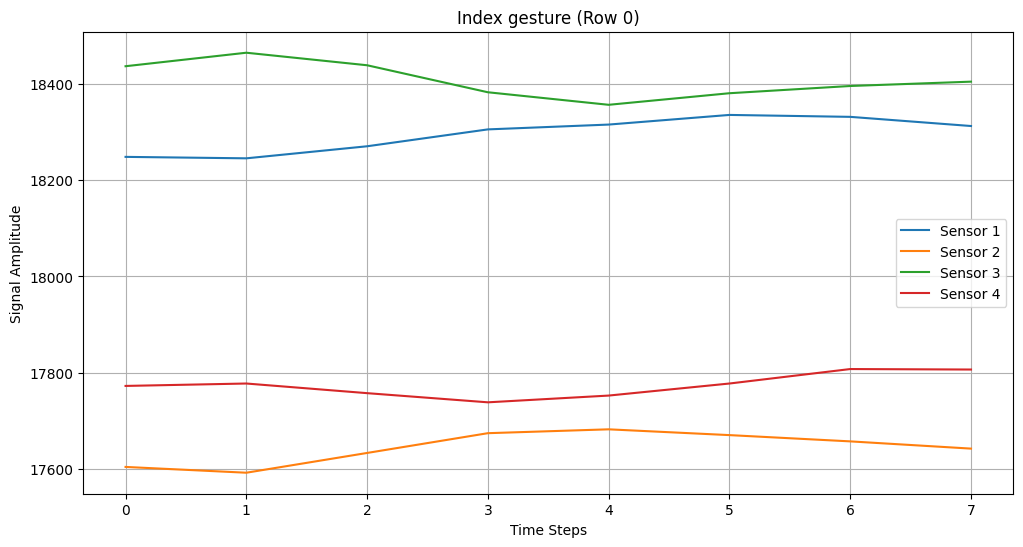

In [13]:
plot_time_signals(index_df, row_index=0, title='Index gesture')

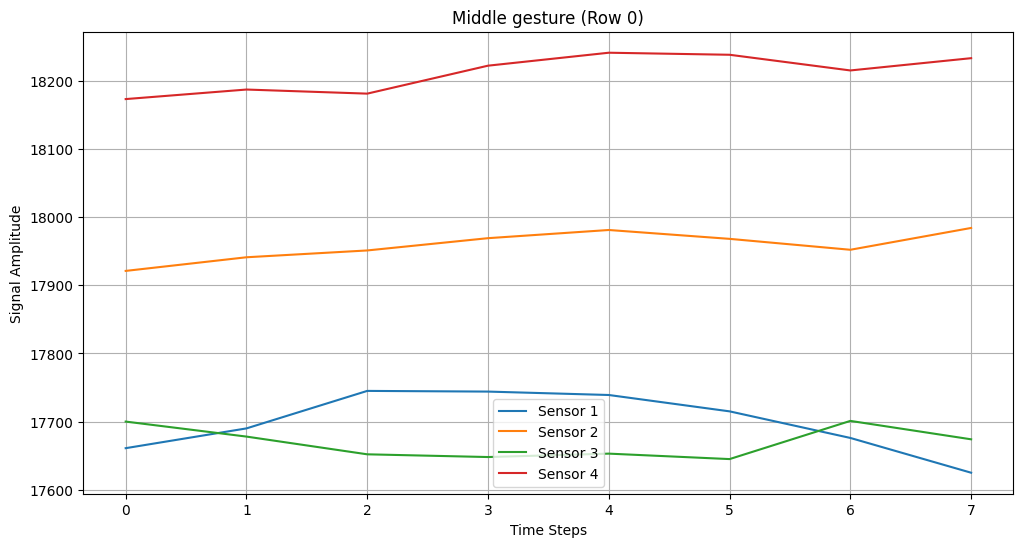

In [14]:
plot_time_signals(middle_df, row_index=0, title='Middle gesture')

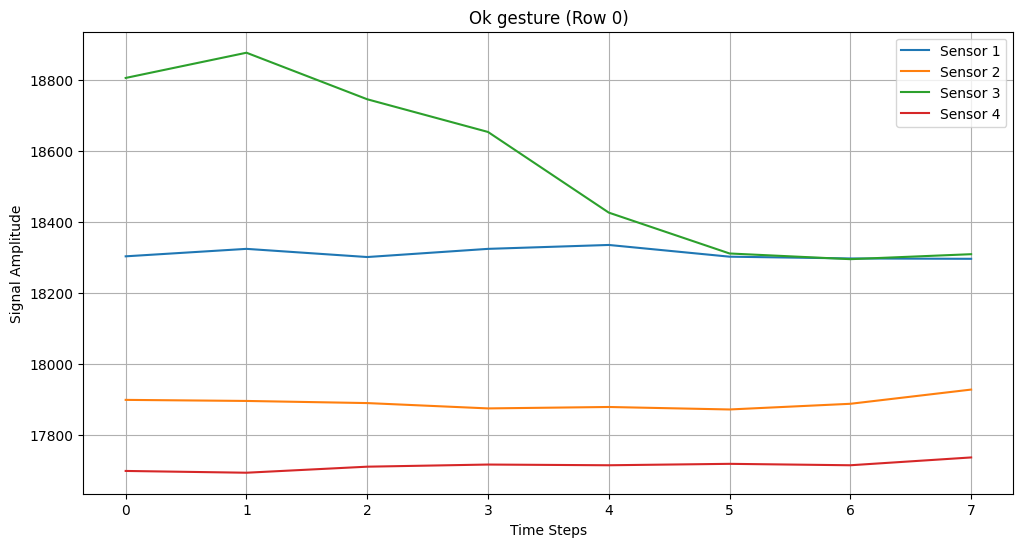

In [15]:
plot_time_signals(ok_df, row_index=0, title='Ok gesture')

In [16]:
if plot_all_timeline:
    plot_all_time_signals(fist_df, title='Fist gesture: whole timeline')
    plot_all_time_signals(peace_df, title='Peace gesture: whole timeline')
    plot_all_time_signals(ok_df, title='Ok gesture: whole timeline')
    plot_all_time_signals(index_df, title='Index gesture: whole timeline')
    plot_all_time_signals(middle_df, title='Middle gesture: whole timeline')

## Preprocessing pipeline tuning

Baseline signal provided
Baseline noise:  0.3833046908861373
Baseline noise:  0.38372745433189287
Baseline noise:  0.3845380643450469
Baseline noise:  0.3846271318923124


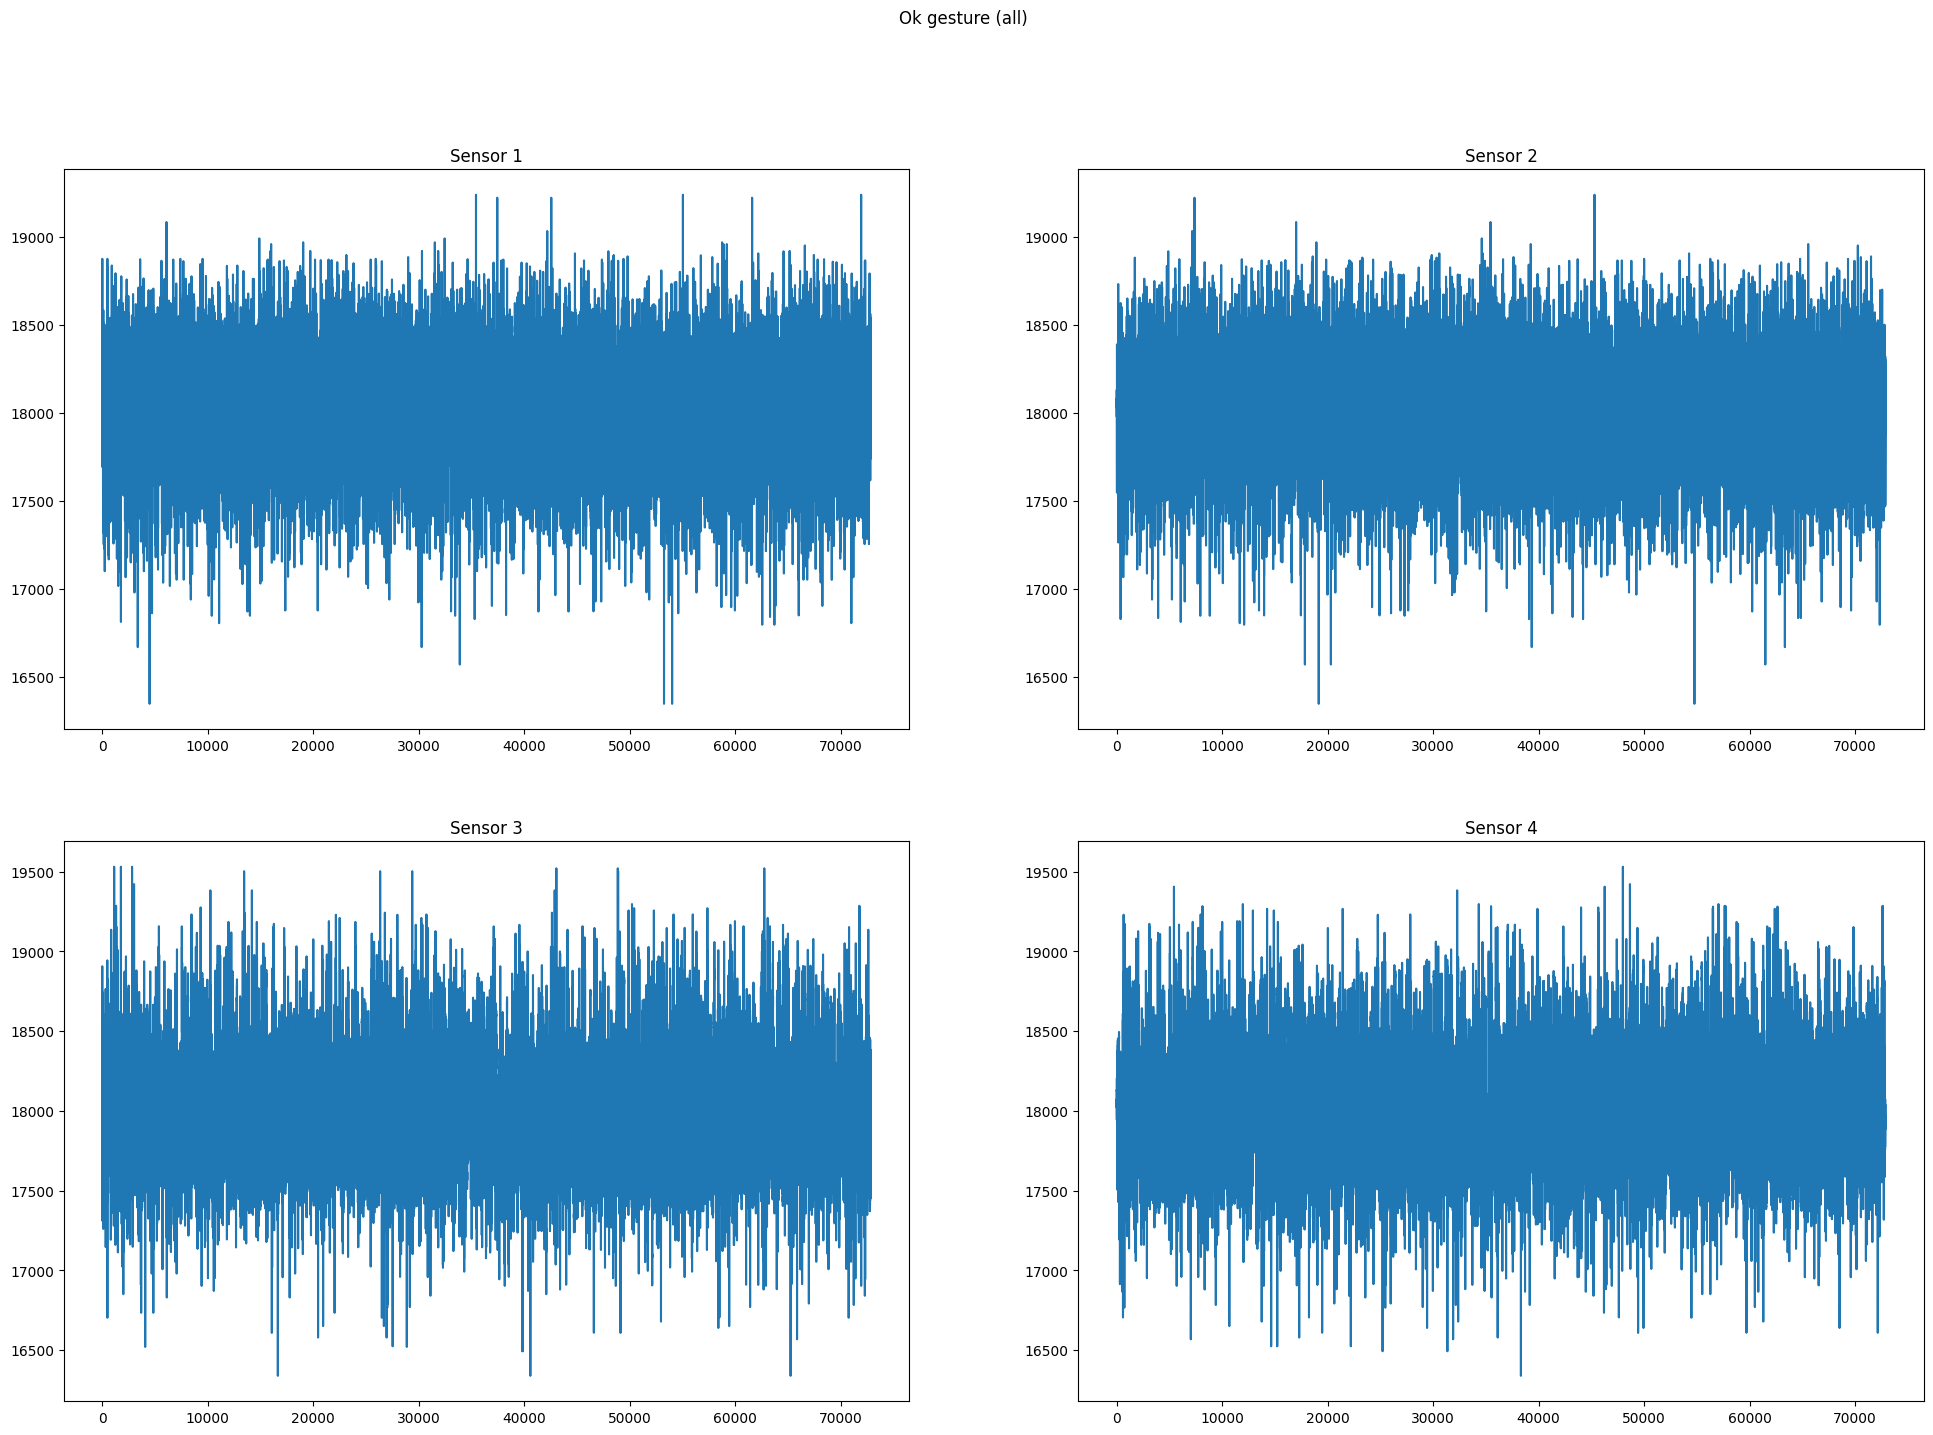

Raw SNR:  22.404081095979734
Processed SNR:  3.7875801045556674
Raw SNR:  22.400501308831565
Processed SNR:  3.7349033170582686
Raw SNR:  22.394706089755637
Processed SNR:  3.908873778407684
Raw SNR:  22.391944506364695
Processed SNR:  3.8991181395154455


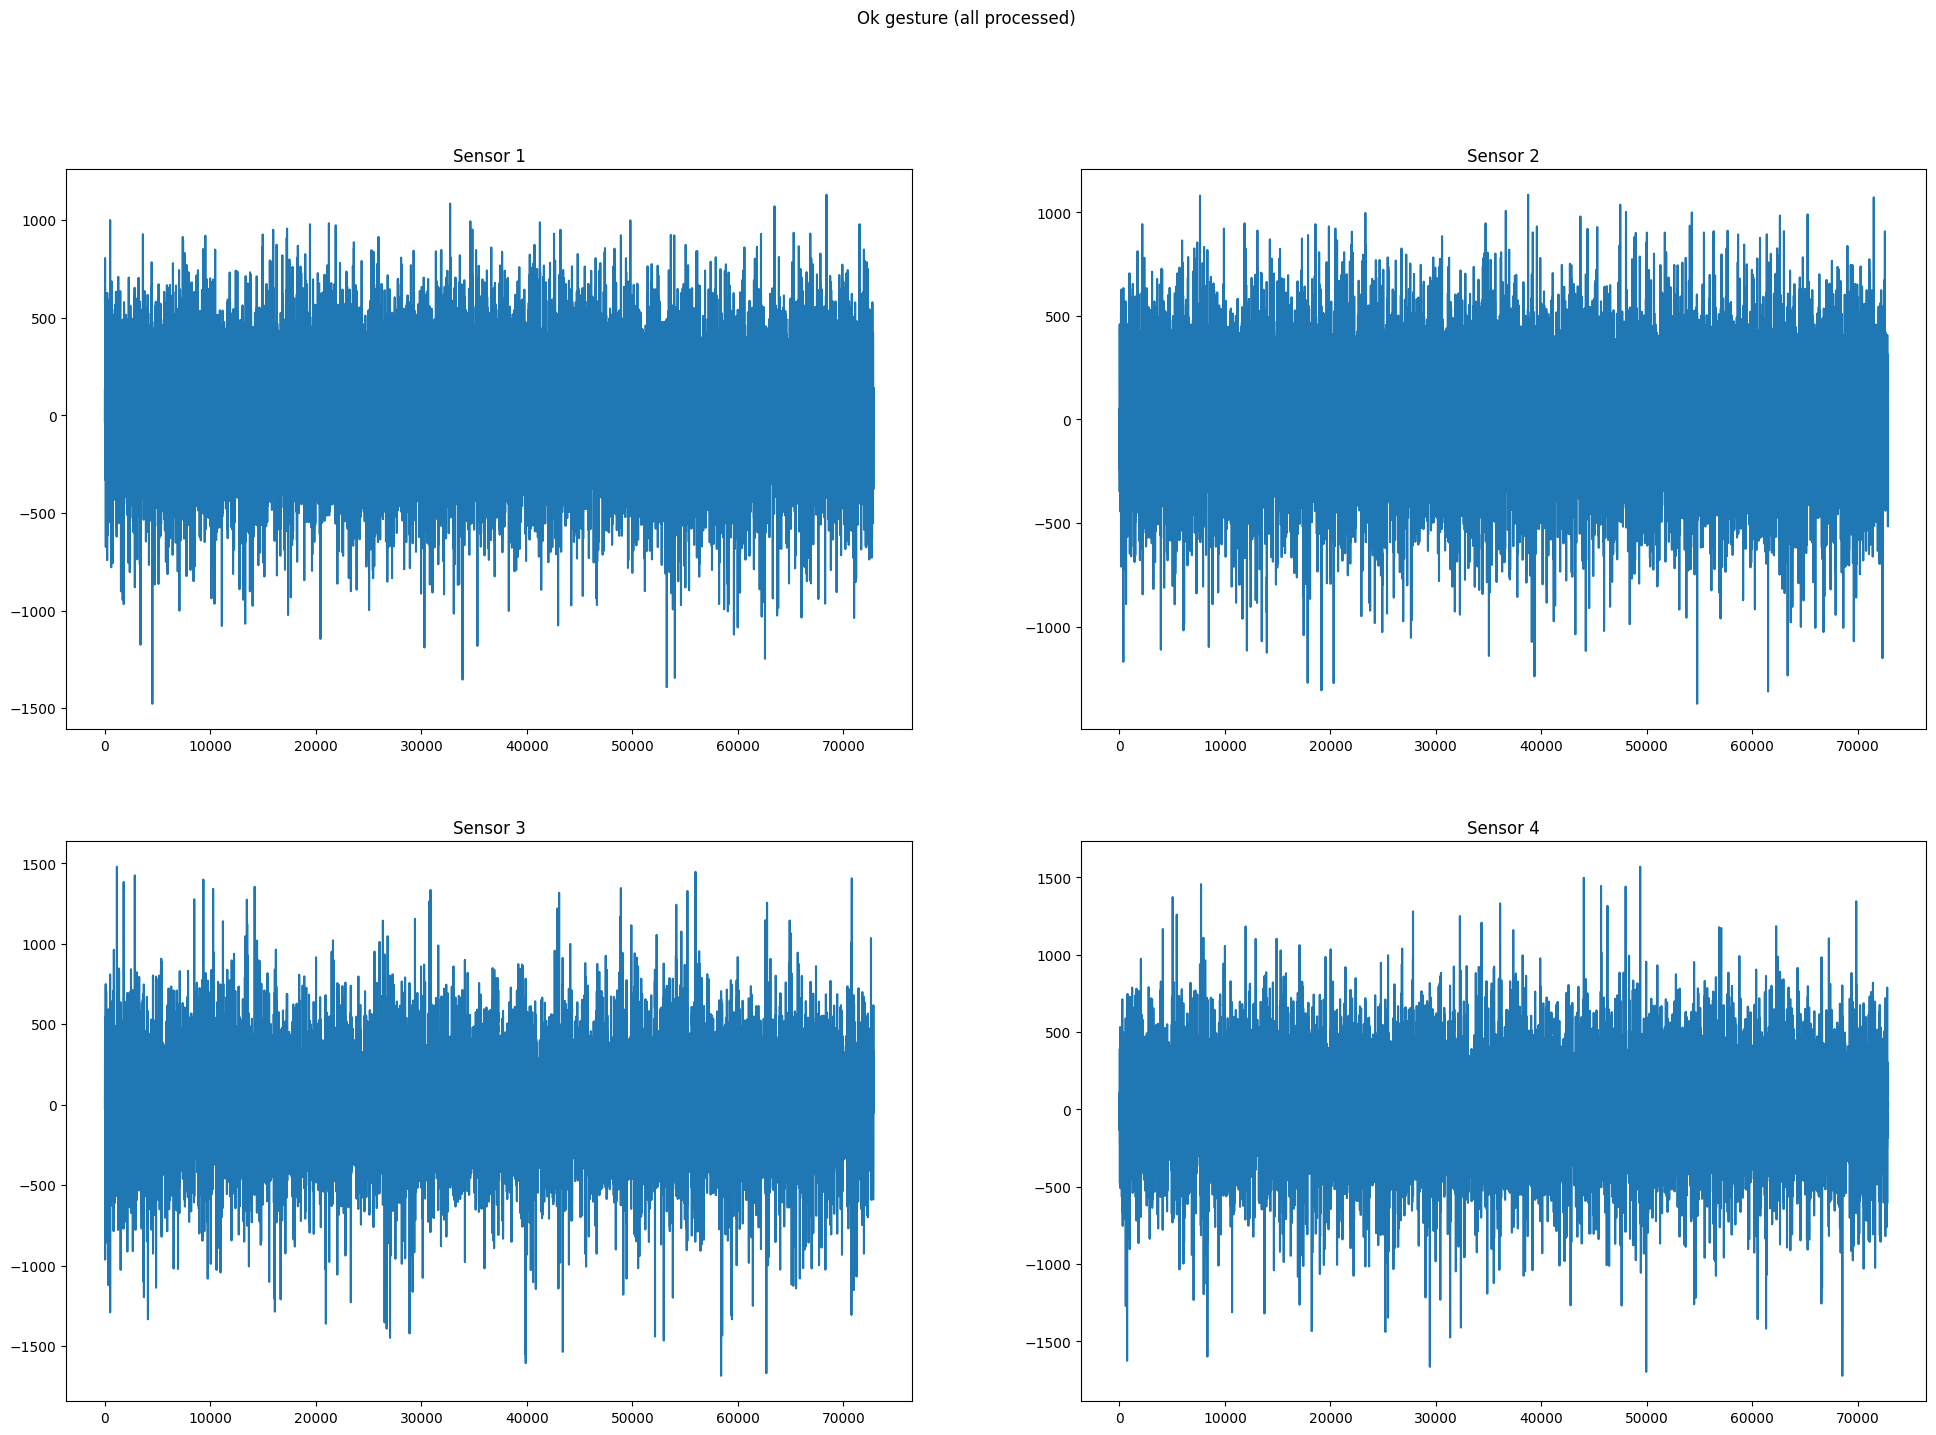

In [17]:
def plot_signal(data, row_index, title):
    # Split the row into 8 groups corresponding to sensors
    signals = np.array_split(data, num_sensors)

    # Plot each sensor's signal
    plt.figure(figsize=(12, 6))
    for i, signal in enumerate(signals):
        plt.plot(signal, label=f'Sensor {i + 1}')
    
    plt.title(f"{title} (Row {row_index})")
    plt.xlabel("Time Steps")
    plt.ylabel("Signal Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_all_signals(preprocessor, all_data, title, filter=False): 
    # Plot each sensor's signal
    signals = np.array_split(all_data, num_sensors)
    fig, axs = plt.subplots(2, 2, figsize=(24, 16))
    axs = axs.flatten()
    for sensor in range(0, num_sensors):
        sigs = signals[sensor]
        sigs = np.array(sigs).flatten()
        # mean = np.mean(sigs, axis=0)
        # std = np.std(sigs, axis=0)
        # sigs = (sigs - mean) #/ std
        if filter:
            print('Raw SNR: ', preprocessor.signaltonoise(sigs, sensor))
            sigs = preprocessor.preprocess(sigs, sensor)
            print('Processed SNR: ', preprocessor.signaltonoise(sigs, sensor))

        axs[sensor].set_title(f'Sensor {sensor + 1}')
        axs[sensor].plot(sigs)
    fig.suptitle(title)
    
    plt.show()

# index = 3
# raw_signal = fist_df.iloc[index, :-1].values
# plot_signal(raw_signal, row_index=index, title='Fist gesture')
# preprocessor = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, neutral_df.values, filter_type='band', library='scipy')
# proc_data = preprocessor.preprocess(raw_signal)
# plot_signal(proc_data, row_index=index, title='Fist gesture (processed)')

# preprocessor = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, neutral_df.iloc[:, :-1].values, filter_type='highlow', library='scipy')
# raw_signal = fist_df.iloc[:, :-1].values
# plot_all_signals(preprocessor, raw_signal, title='Fist gesture (all)', filter=False)
# plot_all_signals(preprocessor, raw_signal, title='Fist gesture (all processed)', filter=True)
# preprocessor = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, neutral_df.iloc[:, :-1].values, filter_type='band', library='scipy')
# raw_signal = fist_df.iloc[:, :-1].values
# plot_all_signals(preprocessor, raw_signal, title='Fist gesture (all)', filter=False)
# plot_all_signals(preprocessor, raw_signal, title='Fist gesture (all processed)', filter=True)

# preprocessor = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, baseline_array.flatten(), filter_type='highlow', library='libemg')
# raw_signal = ok_df.values
# plot_all_signals(preprocessor, raw_signal, title='Ok gesture (all)', filter=False)
# plot_all_signals(preprocessor, raw_signal, title='Ok gesture (all processed)', filter=True)

preprocessor = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, baseline_array.flatten(), filter_type='band', library='libemg')
raw_signal = ok_df.values
plot_all_signals(preprocessor, raw_signal, title='Ok gesture (all)', filter=False)
plot_all_signals(preprocessor, raw_signal, title='Ok gesture (all processed)', filter=True)

# # preprocessor = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, neutral_df.iloc[:, :-1].values, filter_type='highlow', library='libemg')
# raw_signal = fist_df.iloc[:, :-1].values
# plot_all_signals(preprocessor, raw_signal, title='Fist gesture (all)', filter=False)
# plot_all_signals(preprocessor, raw_signal, title='Fist gesture (all processed)', filter=True)

# preprocessor = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, neutral_df.iloc[:, :-1].values, filter_type='band', library='libemg')
# raw_signal = fist_df.iloc[:, :-1].values
# plot_all_signals(preprocessor, raw_signal, title='Fist gesture (all)', filter=False)
# plot_all_signals(preprocessor, raw_signal, title='Fist gesture (all processed)', filter=True)

## Class distribution

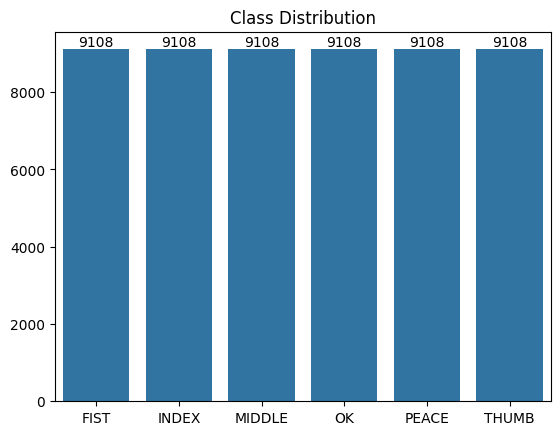

In [18]:
ax = sns.barplot(x=Classes._member_names_, y=[len(fist_df), len(index_df), len(middle_df), len(ok_df), len(peace_df), len(thumb_df)])
ax.bar_label(ax.containers[0])

plt.title('Class Distribution')
plt.show()

## Sensor correlation analysis

/tmp/ipykernel_31099/1905701966.py:1: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  sensor_means = sensor_data.groupby(np.arange(sensor_data.shape[1]) // 8, axis=1).mean()


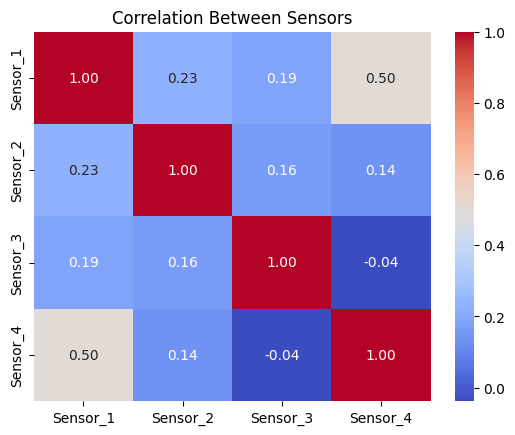

In [19]:
sensor_means = sensor_data.groupby(np.arange(sensor_data.shape[1]) // 8, axis=1).mean()

sensor_means.columns = [f"Sensor_{i+1}" for i in range(num_sensors)]

correlation = sensor_means.corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Sensors")
plt.show()

## Dimensionality Reduction

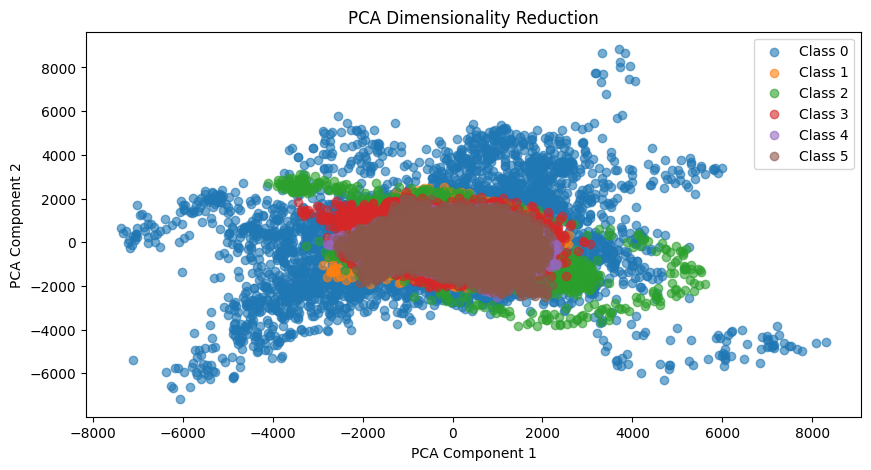

In [20]:
# PCA Dimensionality Reduction to 2 components
pca = PCA(n_components=2)
shape = sensor_data.shape
signals = np.array_split(sensor_data.values.flatten(), num_sensors)
for sensor in range(0, num_sensors):
    sigs = signals[sensor]
    sigs = np.array(sigs).flatten()
    sigs = preprocessor.preprocess(sigs, sensor)
    signals[sensor] = sigs

sensor_preproc = np.asarray(signals).flatten().reshape(shape)
pca_result = pca.fit_transform(sensor_preproc)

# Plot PCA results
plt.figure(figsize=(10, 5))
for class_id in np.unique(labels):
    plt.scatter(pca_result[labels == class_id, 0], pca_result[labels == class_id, 1], label=f'Class {class_id}', alpha=0.6)
plt.title("PCA Dimensionality Reduction")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

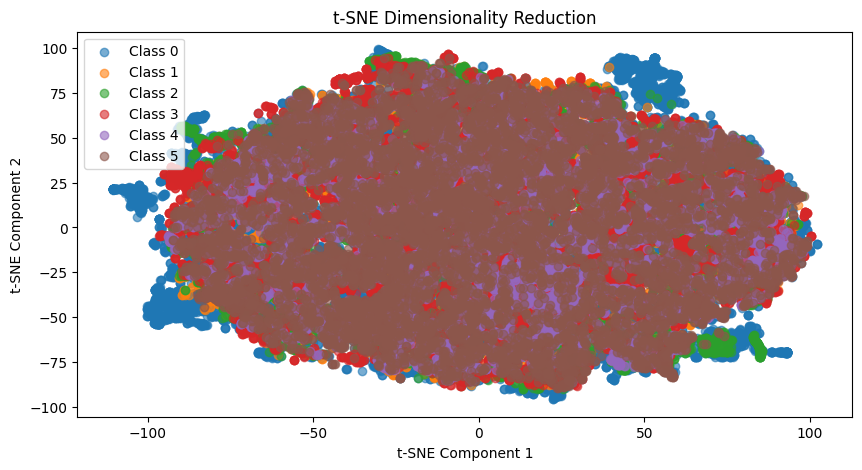

In [38]:
# # t-SNE Dimensionality Reduction to 2 components
tsne = TSNE(n_components=2, perplexity=30, random_state=random_state)
tsne_result = tsne.fit_transform(sensor_preproc)

# Plot t-SNE results
plt.figure(figsize=(10, 5))
for class_id in np.unique(labels):
    plt.scatter(tsne_result[labels == class_id, 0], tsne_result[labels == class_id, 1], label=f'Class {class_id}', alpha=0.6)
plt.title("t-SNE Dimensionality Reduction")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend()
plt.show()

## Train networks

In [18]:
preprocessor = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, baseline_array.flatten(), filter_type='band', library='scipy')
preprocessor2 = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, baseline_array.flatten(), filter_type='band', library='libemg')
# preprocessor3 = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, baseline_array.flatten(), filter_type='band', library='nk2')

Baseline signal provided
Baseline noise:  0.3833046908861373
Baseline noise:  0.38372745433189287
Baseline noise:  0.3845380643450469
Baseline noise:  0.3846271318923124
Baseline signal provided
Baseline noise:  0.3833046908861373
Baseline noise:  0.38372745433189287
Baseline noise:  0.3845380643450469
Baseline noise:  0.3846271318923124


In [19]:
from libemg.utils import get_windows
from libemg.feature_extractor import FeatureExtractor

def preprocess_per_sensor(df, preprocessor, class_name, num_sensors=4, window_size=200, window_increment=100):
    raw_signal = df.values
    shape = raw_signal.shape
    signals = np.array_split(raw_signal.flatten(), num_sensors)
    for sensor in range(0, num_sensors):
        sigs = signals[sensor]
        sigs = np.array(sigs).flatten()
        sigs = preprocessor.preprocess(sigs, sensor)
        sigs = preprocessor2.preprocess(sigs, sensor)
        # sigs = preprocessor3.preprocess(sigs, sensor)
        signals[sensor] = sigs
    raw_signal = np.asarray(signals).flatten().reshape(shape)
    raw_signal = np.hstack([raw_signal[:, i::8] for i in range(8)])
    raw_signal = raw_signal.reshape(-1, num_sensors)
    raw_signal = get_windows(raw_signal, window_size=window_size, window_increment=window_increment)
    
    features_preshaped = raw_signal
    raw_signal = raw_signal.reshape(raw_signal.shape[0], -1)
    raw_signal = np.hstack((raw_signal, np.full((raw_signal.shape[0], 1), class_name)))
    return raw_signal, features_preshaped

def get_features_per_sensor(windows, feature_group='HTD'):
    fe = FeatureExtractor()
    
    if feature_group not in fe.get_feature_groups().keys():
        raise ValueError(f"Invalid feature group: {feature_group}") 

    features_fist = fe.extract_feature_group(feature_group, windows, array=True)
    return features_fist


In [78]:
windows[Classes.FIST]

array([[[-1.26887595e+00,  3.58999116e+01,  7.59381933e+01, ...,
         -2.89609455e+02, -4.55904975e+02, -5.79406734e+02],
        [-7.85649819e+01, -1.17022826e+02, -9.51463506e+01, ...,
         -3.72713413e+02, -8.60004885e+01,  1.85125729e+02],
        [-8.40870232e+01, -3.17626866e+01, -1.98298475e+01, ...,
          4.26873832e+01, -1.49892734e+02, -2.57425771e+02],
        [-4.65028116e+01, -4.44609590e+01, -2.17547561e+01, ...,
          5.63500706e+02,  4.58478191e+02,  4.28792557e+02]],

       [[-2.20699476e+02, -3.64480556e+02, -5.27027793e+02, ...,
          6.22206079e+01, -1.24192545e+02, -1.54334624e+02],
        [-2.14784418e+02, -1.88836258e+02, -1.52818246e+01, ...,
         -8.41005503e+02, -6.05756964e+02, -5.05729305e+02],
        [ 6.00336016e+01,  3.09000657e+02,  1.94876661e+02, ...,
          1.56437028e+02,  2.09381535e+02,  2.89228199e+02],
        [ 5.71121158e+01, -6.14632101e+00,  1.22817650e+02, ...,
          6.51226029e+02,  3.92874822e+02,  1.98639

In [20]:
windows = [[] for _ in range(num_classes)]
fist_array, windows[Classes.FIST] = preprocess_per_sensor(fist_df, preprocessor, Classes.FIST)
index_array, windows[Classes.INDEX] = preprocess_per_sensor(index_df, preprocessor, Classes.INDEX)
middle_array, windows[Classes.MIDDLE] = preprocess_per_sensor(middle_df, preprocessor, Classes.MIDDLE)
ok_array, windows[Classes.OK] = preprocess_per_sensor(ok_df, preprocessor, Classes.OK)
peace_array, windows[Classes.PEACE] = preprocess_per_sensor(peace_df, preprocessor, Classes.PEACE)
thumb_array, windows[Classes.THUMB] = preprocess_per_sensor(thumb_df, preprocessor, Classes.THUMB)

features = [[] for _ in range(num_classes)]
for i in range(num_classes):
    features[i] = get_features_per_sensor(windows[i])

# we have 4 features per sensor, 4 sensors, and 6 classes
# with window size 200 and increment 100, we have 727 per feature
# fist_feat_array = features[Classes.FIST]['MAV'] # 727 x 4
fist_feat_array = np.hstack((features[Classes.FIST], np.full((features[Classes.FIST].shape[0], 1), Classes.FIST)))
index_feat_array = np.hstack((features[Classes.INDEX], np.full((features[Classes.INDEX].shape[0], 1), Classes.INDEX)))
middle_feat_array = np.hstack((features[Classes.MIDDLE], np.full((features[Classes.MIDDLE].shape[0], 1), Classes.MIDDLE)))
ok_feat_array = np.hstack((features[Classes.OK], np.full((features[Classes.OK].shape[0], 1), Classes.OK)))
peace_feat_array = np.hstack((features[Classes.PEACE], np.full((features[Classes.PEACE].shape[0], 1), Classes.PEACE)))
thumb_feat_array = np.hstack((features[Classes.THUMB], np.full((features[Classes.THUMB].shape[0], 1), Classes.THUMB)))

In [21]:
X = np.vstack((fist_array[:, :-1], index_array[:, :-1], middle_array[:, :-1], ok_array[:, :-1], peace_array[:, :-1], thumb_array[:, :-1]))
y = np.vstack((fist_array[:, -1][:, np.newaxis], index_array[:, -1][:, np.newaxis], middle_array[:, -1][:, np.newaxis], ok_array[:, -1][:, np.newaxis], peace_array[:, -1][:, np.newaxis], thumb_array[:, -1][:, np.newaxis])).squeeze()

X_feat = np.vstack((fist_feat_array[:, :-1], index_feat_array[:, :-1], middle_feat_array[:, :-1], ok_feat_array[:, :-1], peace_feat_array[:, :-1], thumb_feat_array[:, :-1]))
y_feat = y

In [22]:
print(X.shape, y.shape, X_feat.shape, y_feat.shape)

(4362, 800) (4362,) (4362, 16) (4362,)


In [23]:
print(X.max(), X.min(), X_feat.max(), X_feat.min())

3661.0610527784165 -3507.9462363866696 80415.74767873652 2.0


Use separate scalars for raw data and features and save both:

In [24]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

with open("scaler_raw_data.pkl", "wb") as f:
    dump(scaler, f, protocol=5)

In [25]:
scaler = StandardScaler()

X_feat = scaler.fit_transform(X_feat)

with open("scalar_features.pkl", "wb") as f:
    dump(scaler, f, protocol=5)

In [26]:
print(X.max(), X.min(), X_feat.max(), X_feat.min())

11.302012547582104 -11.13039655863922 5.363489408413035 -3.401179537184643


In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=random_state)
X_train_feat, X_test_feat, y_train_feat, y_test_feat = train_test_split(X_feat, y_feat, test_size=0.2, shuffle=True, random_state=random_state)

In [28]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape
X_train_feat.shape, X_test_feat.shape, y_train_feat.shape, y_test_feat.shape

((3489, 16), (873, 16), (3489,), (873,))

In [29]:
# Count classes in y_test
unique, counts = np.unique(y_test, return_counts=True)
unique, counts

(array([0., 1., 2., 3., 4., 5.]), array([163, 149, 151, 147, 121, 142]))

## Classical models

In [30]:
clf = RandomForestClassifier(n_estimators=100, max_features='sqrt', max_depth=100, random_state=random_state)
# clf.fit(X_train, y_train)
clf.fit(X_train_feat, y_train_feat)

RandomForestClassifier(max_depth=100, random_state=42)

In [31]:
depths = [estimator.get_depth() for estimator in clf.estimators_]
min(depths), max(depths)

(18, 26)

In [32]:
with open("random_forest_model.pkl", "wb") as f:
    dump(clf, f, protocol=5)

In [33]:
y_pred = clf.predict(X_train_feat)

print('Classification Report: \n', classification_report(y_train_feat, y_pred))
print('Confusion Matrix: \n', confusion_matrix(y_train_feat, y_pred))

Classification Report: 
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       564
         1.0       1.00      1.00      1.00       578
         2.0       1.00      1.00      1.00       576
         3.0       1.00      1.00      1.00       580
         4.0       1.00      1.00      1.00       606
         5.0       1.00      1.00      1.00       585

    accuracy                           1.00      3489
   macro avg       1.00      1.00      1.00      3489
weighted avg       1.00      1.00      1.00      3489

Confusion Matrix: 
 [[564   0   0   0   0   0]
 [  0 578   0   0   0   0]
 [  0   0 576   0   0   0]
 [  0   0   0 580   0   0]
 [  0   0   0   0 606   0]
 [  0   0   0   0   0 585]]


In [34]:
y_pred = clf.predict(X_test_feat)

In [35]:
print('Classification Report: \n', classification_report(y_test_feat, y_pred))
print('Confusion Matrix: \n', confusion_matrix(y_test_feat, y_pred))

Classification Report: 
               precision    recall  f1-score   support

         0.0       0.99      0.93      0.96       163
         1.0       0.67      0.58      0.62       149
         2.0       0.77      0.75      0.76       151
         3.0       0.94      0.94      0.94       147
         4.0       0.66      0.74      0.70       121
         5.0       0.75      0.84      0.79       142

    accuracy                           0.80       873
   macro avg       0.80      0.80      0.80       873
weighted avg       0.80      0.80      0.80       873

Confusion Matrix: 
 [[152   0   4   0   0   7]
 [  0  86  18   0  27  18]
 [  0  14 114   6  12   5]
 [  0   1   3 138   0   5]
 [  0  20   5   1  90   5]
 [  1   8   5   2   7 119]]


## Test different classical ML models

Testing different classification models with common parameters based on https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html.

In [65]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

names = [
    "Nearest Neighbors",
    "Linear SVM",
    "RBF SVM",
    "Decision Tree",
    "Random Forest",
    "Neural Net",
    "AdaBoost",
    "Naive Bayes",
    "QDA",
]

classifiers = [
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025, random_state=random_state),
    SVC(gamma=2, C=1, random_state=random_state),
    DecisionTreeClassifier(max_depth=5, random_state=random_state),
    RandomForestClassifier(
        max_depth=5, n_estimators=10, max_features=1, random_state=random_state
    ),
    MLPClassifier(alpha=1, max_iter=1000, random_state=random_state),
    AdaBoostClassifier(algorithm="SAMME", random_state=random_state),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
]

for name, clf in zip(names, classifiers):
    clf.fit(X_train_feat, y_train_feat)
    y_pred = clf.predict(X_test_feat)
    
    print(f'{name} results:')
    print('Classification Report: \n', classification_report(y_test_feat, y_pred))
    print('Confusion Matrix: \n', confusion_matrix(y_test_feat, y_pred))
    print()

Nearest Neighbors results:
Classification Report: 
               precision    recall  f1-score   support

         0.0       0.94      0.94      0.94       163
         1.0       0.45      0.57      0.50       149
         2.0       0.63      0.54      0.58       151
         3.0       0.92      0.91      0.91       147
         4.0       0.50      0.51      0.50       121
         5.0       0.68      0.56      0.62       142

    accuracy                           0.68       873
   macro avg       0.68      0.67      0.68       873
weighted avg       0.69      0.68      0.69       873

Confusion Matrix: 
 [[154   0   1   0   0   8]
 [  0  85  20   2  34   8]
 [  2  36  82   1  19  11]
 [  0   0   5 134   4   4]
 [  0  36  14   2  62   7]
 [  7  33   9   7   6  80]]

Linear SVM results:
Classification Report: 
               precision    recall  f1-score   support

         0.0       1.00      0.94      0.97       163
         1.0       0.48      0.56      0.52       149
         2.0 

The models used in by libemg are also based on Scikit-Learn and mostly use the [standard parameters](https://github.com/LibEMG/libemg/blob/main/libemg/emg_predictor.py#L225):

```python
model_config = {
    'LDA': (LinearDiscriminantAnalysis, {}),
    'KNN': (KNeighborsClassifier, {"n_neighbors": 5}),
    'SVM': (SVC, {"kernel": "linear", "probability": True, "random_state": 0}),
    'QDA': (QuadraticDiscriminantAnalysis, {}),
    'RF': (RandomForestClassifier, {"random_state": 0}),
    'NB': (GaussianNB, {}),
    'GB': (GradientBoostingClassifier, {"random_state": 0}),
    'MLP': (MLPClassifier, {"random_state": 0, "hidden_layer_sizes": 126})
}
```

## Deep Learning

### Feed Forward Neural Network

The FFNN will be trained on the extracted features from the EMG signals.

In [36]:
import torch
import torch.nn as nn

class NeuralNet(nn.Module):
    def __init__(self, layer_sizes, dropout_rates):
        super(NeuralNet, self).__init__()
        
        assert len(layer_sizes) >= 2, "layer_sizes must include at least input and output sizes"
        assert len(dropout_rates) == len(layer_sizes) - 2, "dropout_rates must match the number of hidden layers"
        
        layers = []
        for i in range(len(layer_sizes) - 1):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i + 1]))
            if i < len(dropout_rates):  # Apply dropout only to hidden layers
                layers.append(nn.ReLU())
                layers.append(nn.Dropout(dropout_rates[i]))
        
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)


In [37]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [62]:
def train_model(model, train_dataloader, test_loader, n_epochs, learning_rate, verbose=True):
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.1)
    
    for epoch in range(n_epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        model.train()
        for inputs, labels in train_dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Compute running loss and accuracy
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        test_accuracy, test_loss = calculate_accuracy(model, test_loader)

        scheduler.step(running_loss / total)
        
        if verbose:
            epoch_loss = running_loss / len(train_dataloader.dataset)
            epoch_accuracy = correct / total * 100

            print(f"Epoch {epoch+1}/{n_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%, Test Accuracy: {test_accuracy:.2f}%")

    return model

def calculate_accuracy(model, test_dataloader, loss_fn=nn.CrossEntropyLoss()):
    running_loss = 0.0
    correct = 0
    total = 0
    model.eval()
    with torch.no_grad():
        for inputs, labels in test_dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return correct / total * 100, running_loss / total

In [112]:
input_size = X_train_feat.shape[1]
output_size = int(y_train_feat.max() + 1)
batch_size = 256
epochs = 200
learning_rate = 0.001

X_train_tensor = torch.tensor(X_train_feat, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_feat, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_feat, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_feat, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [113]:
models_architectures = [
    {'layer_sizes': [input_size, 1024, 1024, output_size], 'dropout_rates': [0.2, 0.2]},
    {'layer_sizes': [input_size, 128, 32, output_size], 'dropout_rates': [0.2, 0.2]},
    {'layer_sizes': [input_size, 32, 32, output_size], 'dropout_rates': [0.2, 0.2]},
    {'layer_sizes': [input_size, 32, output_size], 'dropout_rates': [0.2]},
    {'layer_sizes': [input_size, 8, output_size], 'dropout_rates': [0.2]},
]

In [114]:
models = []

for i, architecture in enumerate(models_architectures):
    model = NeuralNet(architecture['layer_sizes'], architecture['dropout_rates']).to(device)
    print(f"Training model {i+1} with {sum(p.numel() for p in model.parameters())} weights")
    model = train_model(model, train_loader, test_loader, epochs, learning_rate, verbose=False)
    print(f"Model {i+1} train accuracy: {calculate_accuracy(model, train_loader)[0]:.2f}% test accuracy: {calculate_accuracy(model, test_loader)[0]:.2f}%\n")
    models.append(model)

Training model 1 with 1073158 weights
Model 1 train accuracy: 100.00% test accuracy: 79.27%

Training model 2 with 6502 weights
Model 2 train accuracy: 89.57% test accuracy: 80.30%

Training model 3 with 1798 weights
Model 3 train accuracy: 82.43% test accuracy: 79.27%

Training model 4 with 742 weights
Model 4 train accuracy: 80.34% test accuracy: 78.58%

Training model 5 with 190 weights
Model 5 train accuracy: 70.05% test accuracy: 70.33%



In [115]:
model_scripted = torch.jit.script(models[1])
model_scripted.save('ffnn_model.pt')

In [116]:
model_scripted = torch.jit.script(models[3])
model_scripted.save('ffnn_model_2.pt')

In [111]:
X_test_tensor[7]

tensor([-0.8027, -0.5637, -0.7679, -0.6922,  0.9149,  0.1342,  0.1722, -0.4541,
        -0.7184, -0.8352,  0.2943, -1.0434, -0.7359, -0.4516, -1.0125, -1.0222])

In [110]:
logits = models[0](X_test_tensor[7].unsqueeze(0).to(device))
shifted_logits = logits - logits.min(dim=1, keepdim=True).values
normalized_logits = shifted_logits / (shifted_logits.sum(dim=1, keepdim=True) + 1e-8)
print(logits)
print(normalized_logits)

tensor([[-16.1463,  -1.4674,   7.8897, -12.5570,   4.5144,  -5.7406]],
       device='cuda:0', grad_fn=<AddmmBackward0>)
tensor([[0.0000, 0.2001, 0.3276, 0.0489, 0.2816, 0.1418]], device='cuda:0',
       grad_fn=<DivBackward0>)


In [98]:
gc.collect()

351

### LSTM (Long Short-Term Memory)

Unlike the FFNN that was trained on the extracted features, the LSTM will be trained on the raw EMG signals (time series).

In [64]:
class PureLSTM(nn.Module):

    def __init__(self, n_features, n_hidden, n_sequence, n_layers, n_classes, bidirectional=False):
        super(PureLSTM, self).__init__()

        self.n_features = n_features
        self.n_hidden = n_hidden
        self.n_sequence = n_sequence
        self.n_layers = n_layers
        self.n_classes = n_classes
        self.bidirectional = bidirectional

        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=n_hidden,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=bidirectional
        )

        self.linear_1 = nn.Linear(in_features=n_hidden * (2 if bidirectional else 1), out_features=128)
        self.dropout_1 = nn.Dropout(p=0.2)

        self.linear_2 = nn.Linear(in_features=128, out_features=n_classes)

    def forward(self, x):
        device = x.device
        hidden = (
            torch.zeros(self.n_layers * (2 if self.bidirectional else 1), x.shape[0], self.n_hidden).to(device),
            torch.zeros(self.n_layers * (2 if self.bidirectional else 1), x.shape[0], self.n_hidden).to(device),
        )

        out, (hs, cs) = self.lstm(x.view(len(x), self.n_sequence, -1), hidden)
        out = out[:, -1, :]

        out = self.linear_1(out)
        out = self.dropout_1(out)
        out = self.linear_2(out)

        return out

In [73]:
n_features = 4
n_sequence = int(X_train.shape[1] / n_features)
epochs = 400
learning_rate = 0.05

print("Train Data Shape ",X_train.shape, y_train.shape)
print("Test Data Shape ",X_test.shape, y_test.shape)

X_train_mod = X_train.reshape(X_train.shape[0], n_features, n_sequence)
X_train_mod = np.swapaxes(X_train_mod, 2, 1)

X_test_mod = X_test.reshape(X_test.shape[0], n_features, n_sequence)
X_test_mod = np.swapaxes(X_test_mod, 2, 1)

print("Train Data Shape ",X_train_mod.shape)
print("Test Data Shape ",X_test_mod.shape)

X_train_tensor = torch.tensor(X_train_mod, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_mod, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Train Data Shape  (3489, 800) (3489,)
Test Data Shape  (873, 800) (873,)
Train Data Shape  (3489, 200, 4)
Test Data Shape  (873, 200, 4)


In [74]:
n_hidden = 16
n_layers = 2
model = PureLSTM(n_features, n_hidden, n_sequence, n_layers, output_size, bidirectional=False).to(device)

In [75]:
print(model)
print(f"Number of weights: {sum(p.numel() for p in model.parameters())}")

PureLSTM(
  (lstm): LSTM(4, 16, num_layers=2, batch_first=True)
  (linear_1): Linear(in_features=16, out_features=128, bias=True)
  (dropout_1): Dropout(p=0.2, inplace=False)
  (linear_2): Linear(in_features=128, out_features=6, bias=True)
)
Number of weights: 6534


In [76]:
model = train_model(model, train_loader, test_loader, epochs, learning_rate)

Epoch 1/400, Loss: 1.8520, Accuracy: 18.11%, Test Accuracy: 16.72%
Epoch 2/400, Loss: 1.7425, Accuracy: 22.10%, Test Accuracy: 24.74%
Epoch 3/400, Loss: 1.6986, Accuracy: 23.62%, Test Accuracy: 23.94%
Epoch 4/400, Loss: 1.6591, Accuracy: 25.82%, Test Accuracy: 34.25%
Epoch 5/400, Loss: 1.4905, Accuracy: 32.01%, Test Accuracy: 36.08%
Epoch 6/400, Loss: 1.4370, Accuracy: 36.14%, Test Accuracy: 38.03%
Epoch 7/400, Loss: 1.3769, Accuracy: 37.32%, Test Accuracy: 36.88%
Epoch 8/400, Loss: 1.3445, Accuracy: 38.49%, Test Accuracy: 39.98%
Epoch 9/400, Loss: 1.2587, Accuracy: 43.82%, Test Accuracy: 50.63%
Epoch 10/400, Loss: 1.4295, Accuracy: 39.78%, Test Accuracy: 39.63%
Epoch 11/400, Loss: 1.2228, Accuracy: 46.78%, Test Accuracy: 55.67%
Epoch 12/400, Loss: 0.9835, Accuracy: 57.52%, Test Accuracy: 58.65%
Epoch 13/400, Loss: 0.9195, Accuracy: 60.02%, Test Accuracy: 60.02%
Epoch 14/400, Loss: 0.8854, Accuracy: 61.39%, Test Accuracy: 59.45%
Epoch 15/400, Loss: 0.8288, Accuracy: 63.11%, Test Accura

In [115]:
model_scripted = torch.jit.script(model)
model_scripted.save('lstm_model.pt')

Try LSTM with bidirectional layers.

In [116]:
n_hidden = 16
n_layers = 2
model = PureLSTM(n_features, n_hidden, n_sequence, n_layers, output_size, bidirectional=True).to(device)

In [117]:
print(model)
print(f"Number of weights: {sum(p.numel() for p in model.parameters())}")

PureLSTM(
  (lstm): LSTM(4, 16, num_layers=2, batch_first=True, bidirectional=True)
  (linear_1): Linear(in_features=32, out_features=128, bias=True)
  (dropout_1): Dropout(p=0.2, inplace=False)
  (linear_2): Linear(in_features=128, out_features=6, bias=True)
)
Number of weights: 14214


In [118]:
model = train_model(model, train_loader, test_loader, epochs, learning_rate)

Epoch 1/200, Loss: 1.7479, Accuracy: 22.61%, Test Accuracy: 27.38%
Epoch 2/200, Loss: 1.7364, Accuracy: 26.77%, Test Accuracy: 19.93%
Epoch 3/200, Loss: 1.7212, Accuracy: 24.45%, Test Accuracy: 25.89%
Epoch 4/200, Loss: 1.6890, Accuracy: 26.54%, Test Accuracy: 26.46%
Epoch 5/200, Loss: 1.6290, Accuracy: 28.63%, Test Accuracy: 29.67%
Epoch 6/200, Loss: 1.5717, Accuracy: 30.93%, Test Accuracy: 29.90%
Epoch 7/200, Loss: 1.6015, Accuracy: 29.18%, Test Accuracy: 29.78%
Epoch 8/200, Loss: 1.5442, Accuracy: 31.73%, Test Accuracy: 32.88%
Epoch 9/200, Loss: 1.5285, Accuracy: 32.27%, Test Accuracy: 31.16%
Epoch 10/200, Loss: 1.6421, Accuracy: 28.40%, Test Accuracy: 28.87%
Epoch 11/200, Loss: 1.6127, Accuracy: 29.92%, Test Accuracy: 26.92%
Epoch 12/200, Loss: 1.6684, Accuracy: 25.94%, Test Accuracy: 22.91%
Epoch 13/200, Loss: 1.6541, Accuracy: 26.02%, Test Accuracy: 27.95%
Epoch 14/200, Loss: 1.5504, Accuracy: 30.44%, Test Accuracy: 33.56%
Epoch 15/200, Loss: 1.5538, Accuracy: 33.59%, Test Accura

In [119]:
model_scripted = torch.jit.script(model)
model_scripted.save('lstm_bidrection_model.pt')

In [120]:
def evaluateModel(outputs, y):
    _, predicted = outputs.max(1)
    test_accuracy = predicted.eq(y).sum().item() / y.size(0) * 100
    return test_accuracy, predicted

model.eval()
with torch.no_grad():
    X_test_tensor = X_test_tensor.to(device)
    y_test_tensor = y_test_tensor.to(device)
    y_hat_test = model(X_test_tensor)
    acc, predicted = evaluateModel(y_hat_test, y_test_tensor)
    print(f"Test Accuracy: {acc:.2f}%")

Test Accuracy: 84.42%


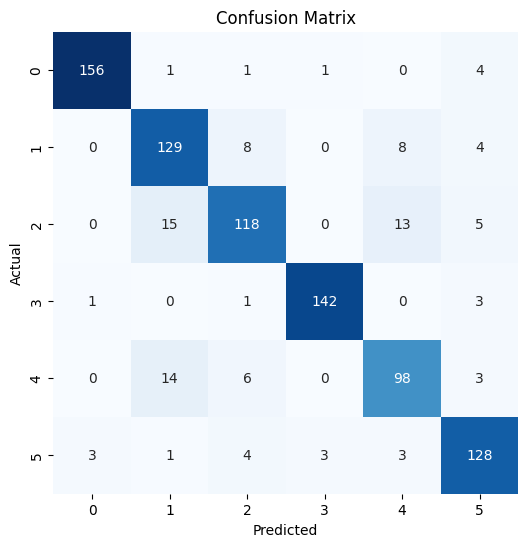

In [117]:
cm = confusion_matrix(y_test, predicted.cpu())

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Transformer

In [118]:
import torch
import torch.nn as nn

class TransformerTimeSeries(nn.Module):
    def __init__(self, n_features, n_sequence, n_hidden, n_heads, n_layers, n_classes, dropout=0.1):
        super(TransformerTimeSeries, self).__init__()
        
        self.n_features = n_features
        self.n_sequence = n_sequence
        
        # Input embedding layer
        self.input_embedding = nn.Linear(n_features, n_hidden)
        
        # Positional encoding
        self.positional_encoding = nn.Parameter(torch.zeros(1, n_sequence, n_hidden))
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=n_hidden,
            nhead=n_heads,
            dim_feedforward=n_hidden * 4,
            dropout=dropout,
            batch_first=True,
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        
        # Fully connected layers
        self.linear_1 = nn.Linear(n_hidden, 128)
        self.dropout_1 = nn.Dropout(p=dropout)
        self.linear_2 = nn.Linear(128, n_classes)

    def forward(self, x):
        # Apply input embedding
        x = self.input_embedding(x)  # Shape: (batch_size, n_sequence, n_hidden)
        
        # Add positional encoding
        x = x + self.positional_encoding
        
        # Pass through Transformer encoder
        x = self.transformer_encoder(x)  # Shape: (batch_size, n_sequence, n_hidden)
        
        # Extract the representation of the last time step
        x = x[:, -1, :]  # Shape: (batch_size, n_hidden)
        
        # Pass through fully connected layers
        x = self.linear_1(x)
        x = self.dropout_1(x)
        x = self.linear_2(x)
        
        return x


In [119]:
n_heads = 4
dropout = 0.2

model = TransformerTimeSeries(n_features, n_sequence, n_hidden, n_heads, n_layers, output_size, dropout).to(device)

In [120]:
model = train_model(model, train_loader, test_loader, epochs, learning_rate)

Epoch 1/200, Loss: 1.6665, Accuracy: 26.94%, Test Accuracy: 28.75%
Epoch 2/200, Loss: 1.4794, Accuracy: 34.80%, Test Accuracy: 39.40%
Epoch 3/200, Loss: 1.3228, Accuracy: 41.42%, Test Accuracy: 42.84%
Epoch 4/200, Loss: 1.2060, Accuracy: 47.49%, Test Accuracy: 53.49%
Epoch 5/200, Loss: 1.0622, Accuracy: 55.03%, Test Accuracy: 54.87%
Epoch 6/200, Loss: 0.9792, Accuracy: 60.68%, Test Accuracy: 60.60%
Epoch 7/200, Loss: 0.8942, Accuracy: 62.25%, Test Accuracy: 62.77%
Epoch 8/200, Loss: 0.8109, Accuracy: 66.24%, Test Accuracy: 64.38%
Epoch 9/200, Loss: 0.7716, Accuracy: 68.04%, Test Accuracy: 64.83%
Epoch 10/200, Loss: 0.7332, Accuracy: 70.08%, Test Accuracy: 62.43%
Epoch 11/200, Loss: 0.7270, Accuracy: 70.08%, Test Accuracy: 72.16%
Epoch 12/200, Loss: 0.7336, Accuracy: 70.39%, Test Accuracy: 68.38%
Epoch 13/200, Loss: 0.6607, Accuracy: 73.63%, Test Accuracy: 74.68%
Epoch 14/200, Loss: 0.6129, Accuracy: 75.72%, Test Accuracy: 72.62%
Epoch 15/200, Loss: 0.5987, Accuracy: 75.35%, Test Accura

In [ ]:
model_scripted = torch.jit.script(model)
model_scripted.save('transformer_model.pt')